In [1]:
!pip install -U -q sentence-transformers git+https://github.com/huggingface/transformers@v4.56.0-Embedding-Gemma-preview

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [10]:
model_ids = ["keepitreal/vietnamese-sbert","dangvantuan/vietnamese-document-embedding", "VoVanPhuc/sup-SimCSE-VietNamese-phobert-base"]


In [ ]:
model_ids.append("BAAI/bge-vi-base")

In [3]:
import torch
from sentence_transformers import SentenceTransformer
from transformers import AutoModel, AutoProcessor

device = "cuda" if torch.cuda.is_available() else "cpu"
# model = SentenceTransformer(model_ids[0]).to(device=device)

# print(f"Device: {model.device}")
# print(model)
# print("Total number of parameters in the model:", sum([p.numel() for _, p in model.named_parameters()]))

In [4]:
print(device)

cpu


In [12]:
models = []
for index, model in enumerate(model_ids):
  print("Load model {}....".format(model))
  model = SentenceTransformer(model,trust_remote_code=True).to(device=device)
  models.append(model)

Load model keepitreal/vietnamese-sbert....
Load model dangvantuan/vietnamese-document-embedding....


Load model VoVanPhuc/sup-SimCSE-VietNamese-phobert-base....


config.json:   0%|          | 0.00/731 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/542M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/270 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/17.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

In [20]:
# The sentences to encode
sentence_high_vn = [
    "Ba con mèo ngồi xung quanh bốn con chó",
    "Bốn con chó ngồi giữa ba con mèo"
]
sentence_low_vn = [
    "Tôi rất thích ăn dưa hấu",
    "Trời Hà Nội hôm nay nóng"
]

sentence_very_low_vn = [
    "Tôi rất thích ăn dưa hấu",
    "Tôi không thích ăn dưa hấu"
]
texts = ["Tôi đang nghiên cứu học máy.", "Machine learning là lĩnh vực rất thú vị."]
stamps = [
    "CONG TY TNHH ABC TRADING",
    "CONG TY TNHH ABD TRADING"
]

real_stamps = [
    "CONG TY TNHH ABC TRADING",
    "CONG TY TNHH AB C TRADING"
]

same_stamps = [
    "CONG TY TNHH ABC TRADING",
    "CONG TY TNHH TRADING ABC"
]

cities = [
    "Sở Công Chính Thành Phố Nội Hà",
    "Sở Công Chính Thành Phố Hà Nội"
]
for sentence in [sentence_high_vn, sentence_low_vn, sentence_very_low_vn, texts, stamps, real_stamps, same_stamps,cities ]:
  print("🙋‍♂️")
  print(sentence)

  for i, model in enumerate(models):
    embeddings = model.encode(sentence)
    similarities = model.similarity(embeddings[0], embeddings[1])
    print("`-> 🤖 score of {}: ".format(model_ids[i]), similarities.numpy()[0][0])


🙋‍♂️
['Ba con mèo ngồi xung quanh bốn con chó', 'Bốn con chó ngồi giữa ba con mèo']
`-> 🤖 score of keepitreal/vietnamese-sbert:  0.9387485
`-> 🤖 score of dangvantuan/vietnamese-document-embedding:  0.9124809
`-> 🤖 score of VoVanPhuc/sup-SimCSE-VietNamese-phobert-base:  0.8588681
🙋‍♂️
['Tôi rất thích ăn dưa hấu', 'Trời Hà Nội hôm nay nóng']
`-> 🤖 score of keepitreal/vietnamese-sbert:  0.12539974
`-> 🤖 score of dangvantuan/vietnamese-document-embedding:  0.15130866
`-> 🤖 score of VoVanPhuc/sup-SimCSE-VietNamese-phobert-base:  0.28851724
🙋‍♂️
['Tôi rất thích ăn dưa hấu', 'Tôi không thích ăn dưa hấu']
`-> 🤖 score of keepitreal/vietnamese-sbert:  0.9296013
`-> 🤖 score of dangvantuan/vietnamese-document-embedding:  0.6122399
`-> 🤖 score of VoVanPhuc/sup-SimCSE-VietNamese-phobert-base:  0.5266435
🙋‍♂️
['Tôi đang nghiên cứu học máy.', 'Machine learning là lĩnh vực rất thú vị.']
`-> 🤖 score of keepitreal/vietnamese-sbert:  0.29321662
`-> 🤖 score of dangvantuan/vietnamese-document-embedding:  0.

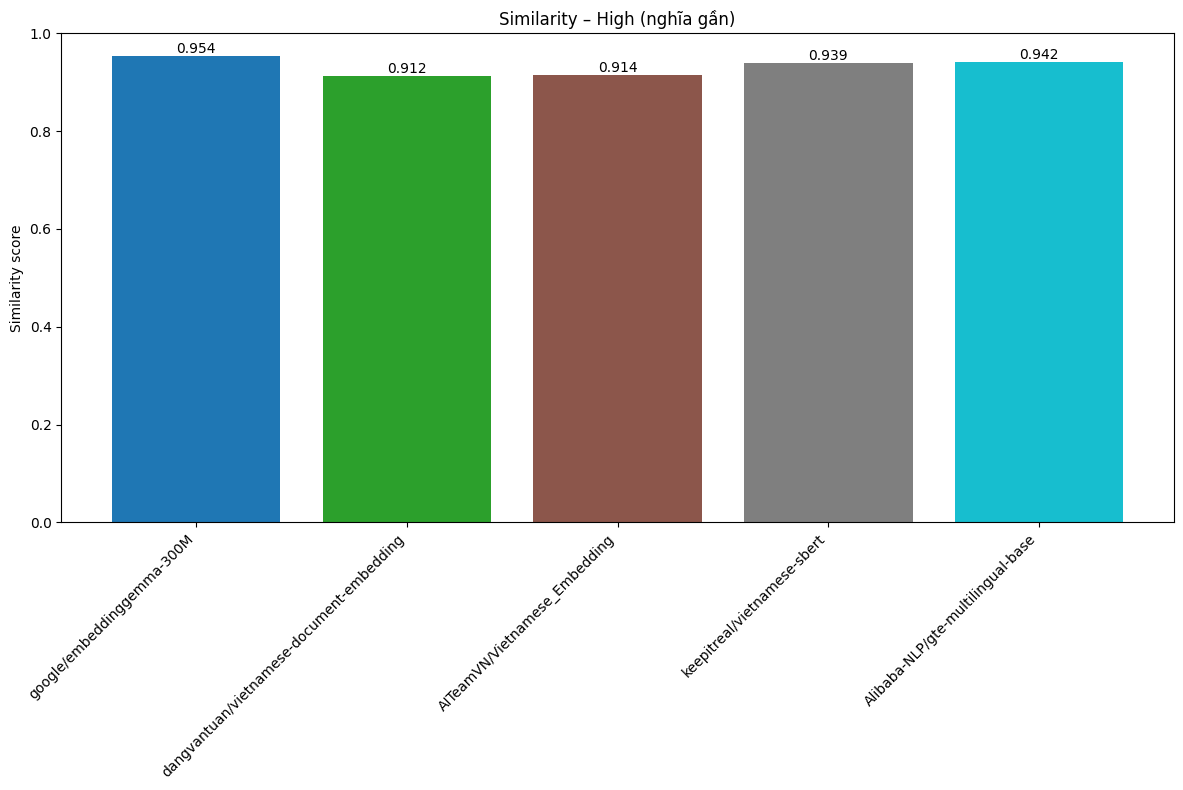

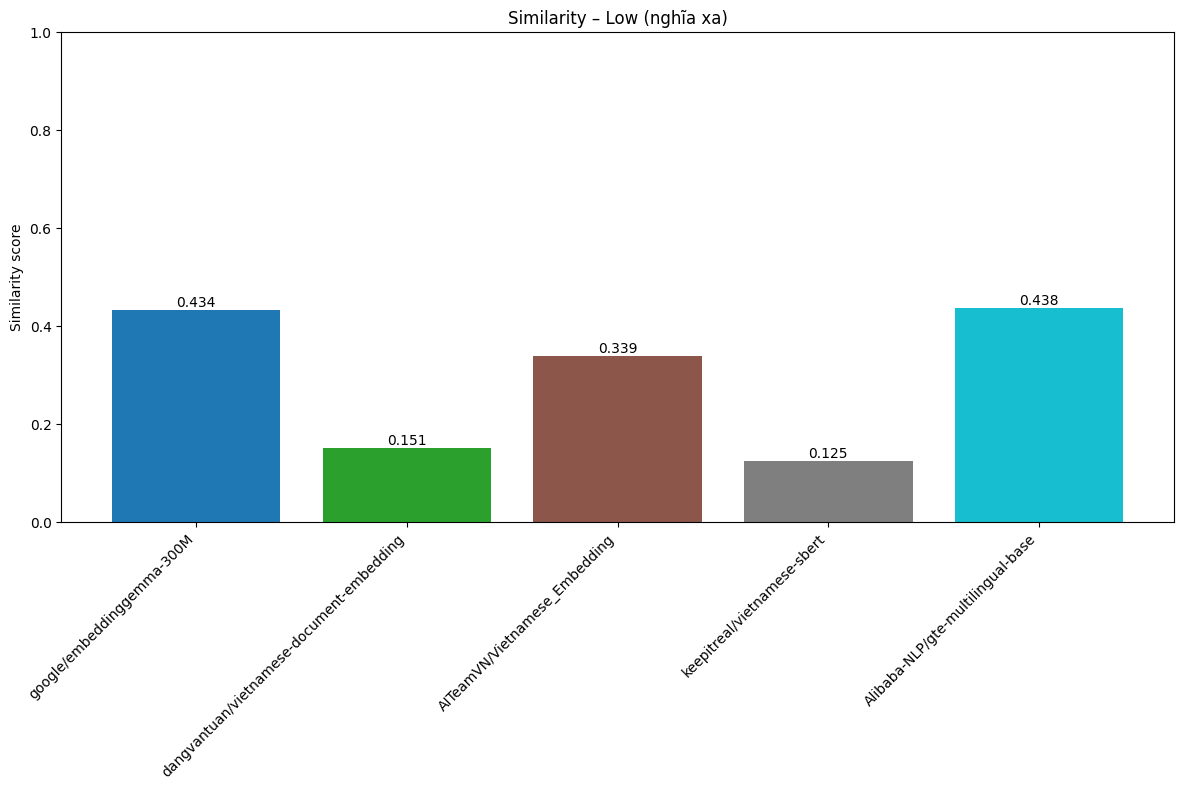

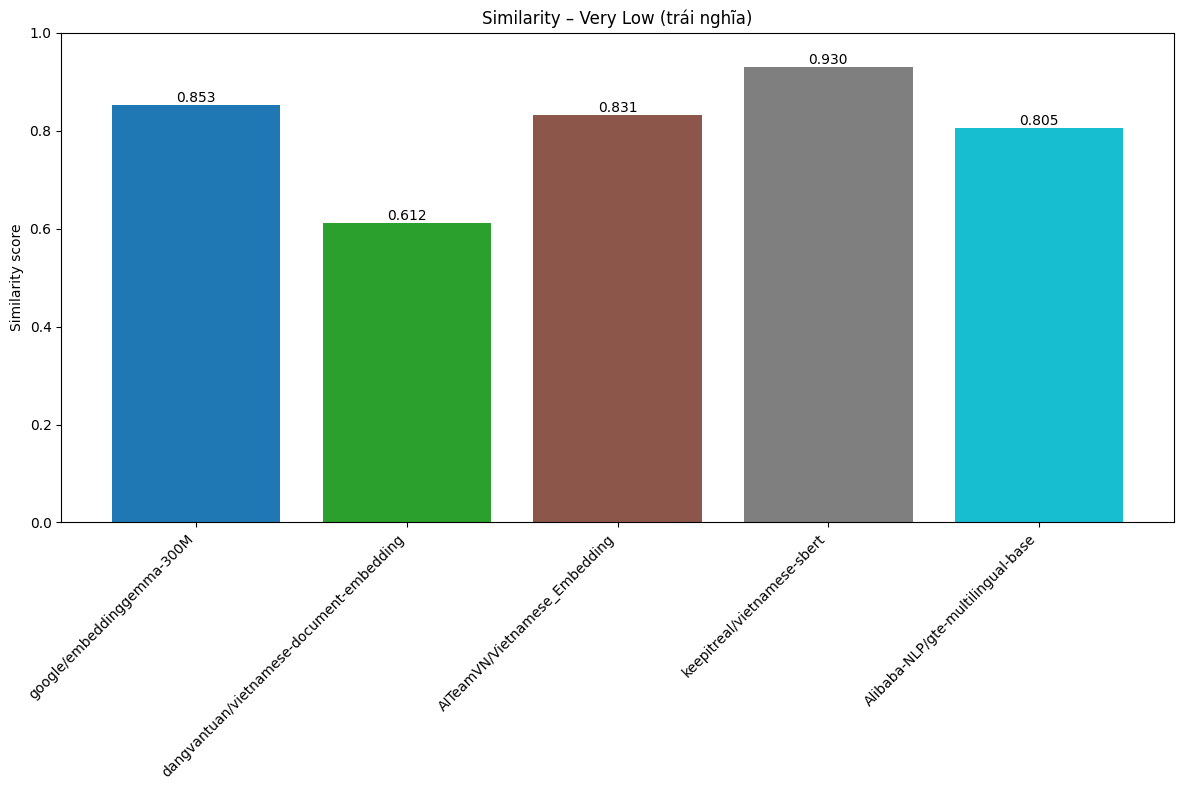

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- Hàm tính similarity ---
def sim_for_pair(model, pair_sentences, use_prompt_sts=False):
    if use_prompt_sts:
        emb = model.encode(pair_sentences, prompt_name="STS")
    else:
        emb = model.encode(pair_sentences)
    sim = model.similarity(emb[0], emb[1]).numpy()[0][0]
    return float(sim)

pairs = [
    ("High (nghĩa gần)", sentence_high_vn),
    ("Low (nghĩa xa)", sentence_low_vn),
    ("Very Low (trái nghĩa)", sentence_very_low_vn),
]

# Lưu kết quả: {pair_name: [score_model1, score_model2,...]}
results = {}

for pair_name, pair_sents in pairs:
    results[pair_name] = []
    for i, model in enumerate(models):
        score = sim_for_pair(model, pair_sents, use_prompt_sts=(i == 0))
        results[pair_name].append(score)

# --- Vẽ 3 biểu đồ: mỗi biểu đồ cho 1 cặp ---
for pair_name, scores in results.items():
    x = np.arange(len(model_ids))  # vị trí cột

    # Tạo danh sách màu khác nhau cho từng model
    colors = plt.cm.tab10(np.linspace(0, 1, len(model_ids)))

    plt.figure(figsize=(12, 8))
    plt.bar(x, scores, tick_label=model_ids, color=colors)

    plt.title(f"Similarity – {pair_name}")
    plt.ylabel("Similarity score")
    plt.ylim(0, 1.0)  # nếu similarity cosine chuẩn hóa thì để (0,1)
    plt.xticks(rotation=45, ha='right')

    # Thêm giá trị lên đầu cột
    for idx, val in enumerate(scores):
        plt.text(x[idx], val, f"{val:.3f}", ha='center', va='bottom')

    plt.tight_layout()
    plt.show()
